In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import(mean_absolute_error,mean_squared_error,r2_score)
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('energydata_complete.csv')
df.head() # show the first 5 rows of the dataset

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [4]:
df.info() # display information about the dataset, including data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

In [5]:
df.describe() # generate descriptive statistics of the dataset, including count, mean, std, min, 25%, 50%, 75%, and max values for each column

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [6]:
df.isnull().sum() # check for missing values in the dataset

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [31]:
X = df.iloc[:, 2:-1]  # All columns except the last one
Y = df['Appliances']  # Target variable

In [28]:
# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1
2133,0,19.890000,45.50,19.200000,45.090000,20.390000,44.290000,19.10,46.700000,17.511111,...,50.000000,17.166667,48.700000,10.300000,761.900000,85.500000,7.500000,23.500000,7.950000,39.240863
19730,0,25.566667,46.56,25.890000,42.025714,27.200000,41.163333,24.70,45.590000,23.200000,...,50.074000,23.200000,46.790000,22.733333,755.200000,55.666667,3.333333,23.666667,13.333333,43.096812
3288,0,22.500000,44.43,21.533333,42.590000,21.963333,44.555000,22.00,40.466667,19.100000,...,41.331111,18.600000,45.530000,6.600000,760.200000,64.000000,8.000000,40.000000,0.200000,42.054659
7730,0,19.790000,38.06,17.200000,40.933333,20.600000,37.163333,18.39,37.000000,18.290000,...,42.590000,18.390000,40.723333,2.100000,741.533333,94.333333,1.000000,48.666667,1.233333,12.615865
8852,0,20.600000,35.29,17.100000,39.790000,20.290000,37.000000,19.50,34.500000,18.200000,...,39.260000,18.926667,40.090000,-0.866667,768.266667,92.333333,1.666667,34.000000,-1.933333,10.897926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0,21.760000,40.90,19.390000,43.090000,23.000000,39.000000,21.50,39.790000,20.100000,...,45.466667,20.356667,40.560000,9.566667,750.466667,77.666667,6.666667,40.000000,5.833333,45.513197
11964,0,22.390000,43.70,22.000000,42.066667,22.700000,41.230000,21.29,44.120000,19.700000,...,47.000000,20.290000,44.290000,17.300000,749.500000,66.000000,2.000000,40.000000,10.900000,34.934752
5390,0,20.290000,35.70,18.200000,37.590000,20.100000,37.590000,18.20,35.290000,18.500000,...,41.700000,17.890000,39.466667,-1.066667,754.900000,87.000000,3.666667,62.666667,-2.933333,19.071358
860,0,21.790000,35.56,20.434000,35.116000,21.200000,36.900000,21.10,35.663333,18.050000,...,39.475000,18.500000,41.466667,2.066667,765.033333,64.333333,1.333333,40.000000,-4.066667,1.050592


In [29]:
model = LinearRegression()  # Create a linear regression model
model.fit(X_train, Y_train)  # Fit the model to the training data

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](26,)","[ 1.93, 0.07,15.91,..., 0.16, 5.01, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](26,)","['lights','T1','RH_1',...,'Visibility','Tdewpoint','rv1']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,23.12
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,26
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(26)


In [35]:
y_pred = model.predict(X_test)  # Make predictions on the test set
y_pred

array([ 43.17846752, 259.0298478 ,  46.77130055, ..., 111.02755877,
        58.20574685,  99.89336735], shape=(3947,))

In [36]:
Y_test

8980      40
2754      90
9132      50
14359     50
8875      70
        ... 
9815      80
9925     100
14088     60
17356     70
17547     50
Name: Appliances, Length: 3947, dtype: int64

In [40]:
comparison = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

   Actual   Predicted
0      40   43.178468
1      90  259.029848
2      50   46.771301
3      50  116.140510
4      70   33.072653
5     120  193.142773
6     120   90.340613
7      70  175.986875
8      50   84.989942
9      70  146.212547


In [51]:
mae = mean_absolute_error(Y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 52.54769287614663


In [54]:
mse = mean_squared_error(Y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 8312.848891755488


In [55]:
rmse = mse ** 0.5

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 91.17482597600879


In [56]:
r2 = r2_score(Y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.16930416505473966


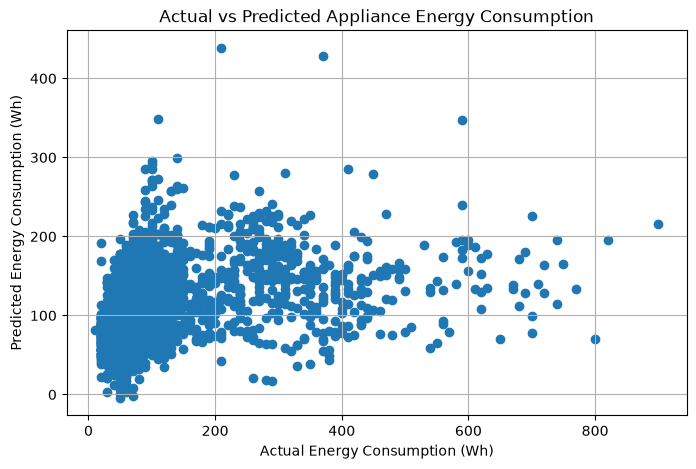

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(Y_test, y_pred)
plt.plot(Y)

plt.xlabel("Actual Energy Consumption (Wh)")
plt.ylabel("Predicted Energy Consumption (Wh)")
plt.title("Actual vs Predicted Appliance Energy Consumption")

plt.grid()
plt.show()